# Laporan Modul 1: Eksplorasi Paralelisme Dasar
## Speedup Analysis dengan Thread/Multiprocessing Sederhana

**Nama:** Rozel Tasri Orama  
**NIM:** 24343023  
**Kelas:** Sesi 202523430063  
**Mata Kuliah:** Komputasi Paralel dan Terdistribusi  

Notebook ini sudah berisi **output tabel dan grafik**, sehingga grafik akan terlihat langsung saat file dibuka di GitHub.

## Spesifikasi Laptop
- **Device:** ASUS TUF Gaming F15 FX506HF_FX506HF
- **Processor:** 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz
- **RAM:** 16.0 GB, 3200 MT/s
- **GPU:** 4 GB, multiple GPUs installed
- **Storage:** 954 GB


## 1. Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-mvps5zy4 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Data Mahasiswa

In [2]:
data_mahasiswa = pd.DataFrame({
    "Keterangan": ["Nama", "NIM", "Kelas"],
    "Data": ["Rozel Tasri Orama", "24343023", "Sesi 202523430063"]
})
data_mahasiswa

,Keterangan,Data
0,Nama,Rozel Tasri Orama
1,NIM,24343023
2,Kelas,Sesi 202523430063


## 3. Hasil Implementasi

In [3]:
serial_result = pd.DataFrame({
    "Program": ["Serial"],
    "Waktu Eksekusi (detik)": [4.8762],
    "Hasil pi": [3.1411396]
})
serial_result

,Program,Waktu Eksekusi (detik),Hasil pi
0,Serial,4.8762,3.14114


In [4]:
parallel_result = pd.DataFrame({
    "Jumlah Proses": [1, 2, 4, 8, 16, 32],
    "Waktu (detik)": [5.0144, 2.8249, 1.9872, 1.5366, 1.5965, 1.5136],
    "Speedup": [0.966, 1.715, 2.438, 3.154, 3.035, 3.201],
    "Efficiency": [0.966, 0.858, 0.6095, 0.394, 0.189, 0.100]
})
parallel_result

,Jumlah Proses,Waktu (detik),Speedup,Efficiency
0,1,5.0144,0.966,0.9660
1,2,2.8249,1.715,0.8580
2,4,1.9872,2.438,0.6095
3,8,1.5366,3.154,0.3940
4,16,1.5965,3.035,0.1890
5,32,1.5136,3.201,0.1000


## 4. Grafik Analisis

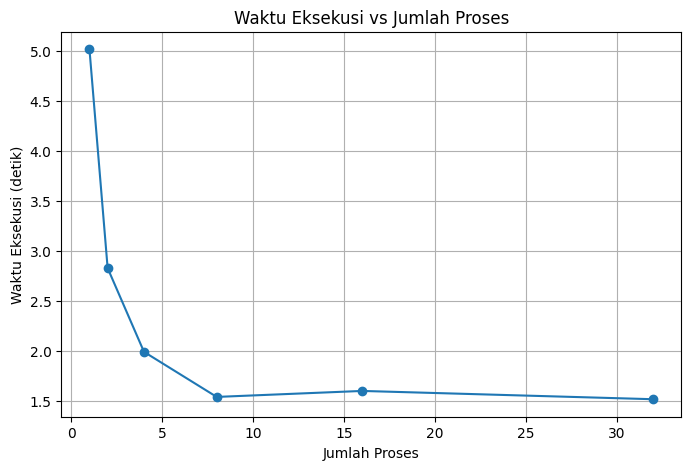

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(parallel_result["Jumlah Proses"], parallel_result["Waktu (detik)"], marker="o")
plt.title("Waktu Eksekusi vs Jumlah Proses")
plt.xlabel("Jumlah Proses")
plt.ylabel("Waktu Eksekusi (detik)")
plt.grid(True)
plt.show()

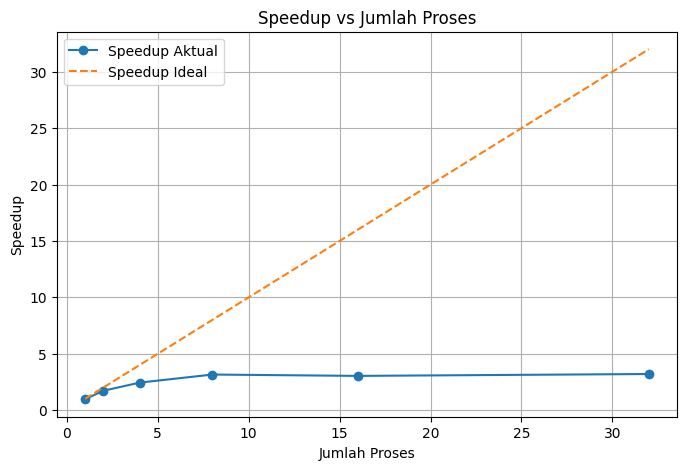

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(parallel_result["Jumlah Proses"], parallel_result["Speedup"], marker="o", label="Speedup Aktual")
plt.plot(parallel_result["Jumlah Proses"], parallel_result["Jumlah Proses"], linestyle="--", label="Speedup Ideal")
plt.title("Speedup vs Jumlah Proses")
plt.xlabel("Jumlah Proses")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)
plt.show()

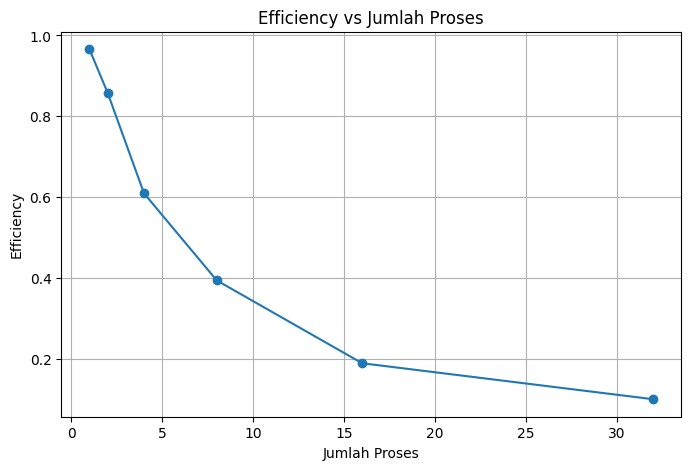

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(parallel_result["Jumlah Proses"], parallel_result["Efficiency"], marker="o")
plt.title("Efficiency vs Jumlah Proses")
plt.xlabel("Jumlah Proses")
plt.ylabel("Efficiency")
plt.grid(True)
plt.show()

## 5. Analisis Hasil

### 5.1 Faktor Overhead
Speedup yang diperoleh tidak mencapai kondisi ideal karena adanya beberapa faktor overhead:

1. Proses pembuatan dan pengelolaan multiprocessing membutuhkan waktu tambahan.
2. Hasil dari setiap proses perlu dikumpulkan dan dijumlahkan kembali.
3. Jumlah proses yang terlalu banyak dapat menyebabkan context switching.
4. Tidak semua bagian program dapat diparalelkan, seperti inisialisasi, pembagian data, dan penggabungan hasil.

Oleh karena itu, penambahan jumlah proses tidak selalu menghasilkan peningkatan performa yang sebanding.

### 5.2 Perbandingan dengan Amdahl's Law
Amdahl's Law digunakan untuk menghitung batas maksimum speedup program paralel.

$$S(n) = \frac{1}{f + \frac{1-f}{n}}$$

Dengan asumsi 5% program tidak dapat diparalelkan dan digunakan 8 proses, maka perhitungannya adalah:


In [8]:
f = 0.05
n = 8
speedup_teoritis = 1 / (f + ((1 - f) / n))
speedup_aktual_8 = parallel_result.loc[parallel_result["Jumlah Proses"] == 8, "Speedup"].iloc[0]

amdahl_comparison = pd.DataFrame({
    "Keterangan": ["Speedup Teoritis Amdahl", "Speedup Aktual 8 Proses"],
    "Nilai": [round(speedup_teoritis, 3), speedup_aktual_8]
})
amdahl_comparison

,Keterangan,Nilai
0,Speedup Teoritis Amdahl,5.926
1,Speedup Aktual 8 Proses,3.154


## 6. Kesimpulan
Berdasarkan praktikum yang telah dilakukan, penggunaan multiprocessing dapat mempercepat proses perhitungan nilai π dibandingkan program serial. Namun, speedup aktual belum mencapai speedup ideal karena adanya overhead seperti pembuatan proses, pembagian tugas, penggabungan hasil, context switching, serta keterbatasan jumlah core CPU.

Efisiensi program semakin menurun ketika jumlah proses semakin banyak. Hal ini menunjukkan bahwa jumlah proses harus disesuaikan dengan kemampuan perangkat keras dan karakteristik program agar paralelisasi dapat berjalan lebih optimal.

## 7. Link Repository GitHub
Setelah file ini di-upload ke repository, link yang dapat digunakan di laporan adalah:

`https://github.com/USERNAME_KAMU/Komputasi-Parallel/blob/main/Modul1.ipynb`
